# Univariate Analysis 📊

**Univariate Analysis** is the simplest form of analyzing data. The prefix *"uni"* means *"one"*, implying that our analysis revolves around **only one variable (or column)** at a time.

Its primary objective is to describe the data, summarize it, and find patterns or distributions in that single feature. It does not look at relationships between multiple variables.

---

### Types of Variables & Analysis Methods:

Depending on the nature of the column, we divide univariate analysis into two categories:

1.  **Categorical Variables** (Non-numeric values, classes, or labels): 
    *   *Examples*: Pclass, Survived, Sex, Embarked.
    *   *Mathematical Tools*: Frequency Distribution, Relative Frequency.
    *   *Visualizations*: Bar Charts (Countplots), Pie Charts.
2.  **Numerical Variables** (Continuous or discrete quantitative numbers):
    *   *Examples*: Age, Fare, PassengerId.
    *   *Mathematical Tools*: Mean, Median, Mode, Standard Deviation, Skewness, Kurtosis.
    *   *Visualizations*: Histograms, KDE (Kernel Density Estimate) / Density Plots, Boxplots.

### 1. Import Libraries & Load Data 📥
We will load our standard data analysis libraries (`pandas`, `numpy`) and visualization libraries (`matplotlib.pyplot`, `seaborn`), and ingest our Titanic `train.csv` dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
df = pd.read_csv('Datasets/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Part A: Univariate Analysis on Categorical Data 🏷️

For categorical data, we want to know the **frequency of each category** (how many times each category occurs) and the **proportion/percentage share** of each category.

### A.1. Frequency Distribution (`value_counts`)
Let's check the frequency distribution of the `Survived` and `Sex` columns using `.value_counts()`.

In [3]:
# Survived counts (0 = No, 1 = Yes)
print("Survival Frequency:")
print(df['Survived'].value_counts())

print("\nGender Frequency:")
print(df['Sex'].value_counts())

Survival Frequency:
Survived
0    549
1    342
Name: count, dtype: int64

Gender Frequency:
Sex
male      577
female    314
Name: count, dtype: int64


### A.2. Countplot (Bar Chart)
A countplot is a bar chart showing the frequency of each category. We use Seaborn's `sns.countplot()` for an elegant visualization.

C:\Users\omdon\AppData\Local\Temp\ipykernel_4808\1362880833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


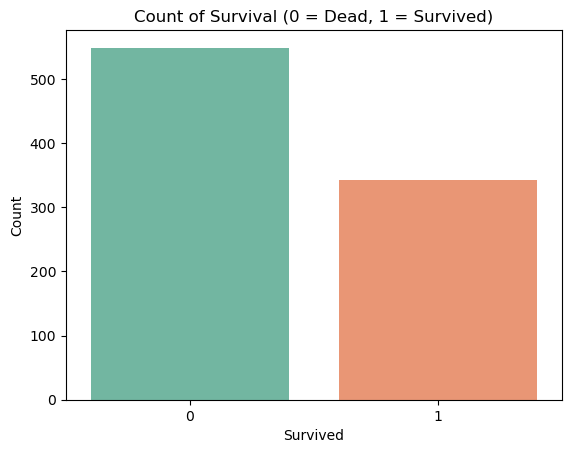

In [4]:
# Visualizing Survival Counts
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Count of Survival (0 = Dead, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

### A.3. Pie Chart
A pie chart is excellent for visualizing the percentage share of each category.

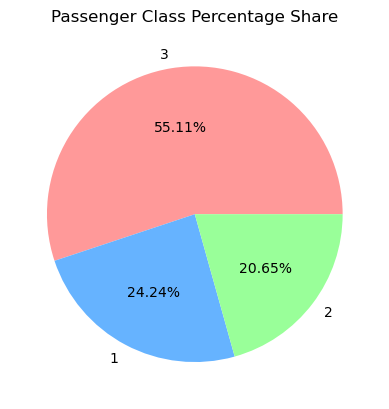

In [5]:
# Percentage of Passengers by Class (Pclass)
df['Pclass'].value_counts().plot(kind='pie', autopct='%.2f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Passenger Class Percentage Share')
plt.ylabel('')
plt.show()

---
## Part B: Univariate Analysis on Numerical Data 📈

For numerical columns, we analyze the **distribution**, **skewness** (asymmetry), **kurtosis** (tailedness), and check for **outliers** (extreme values).

### B.1. Histogram
A histogram segments the continuous column into discrete intervals called **bins** and displays counts inside those bins to show distribution shape.

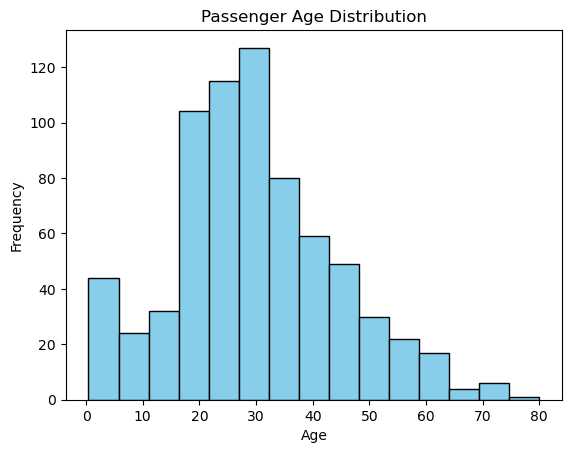

In [6]:
# Age Distribution Histogram
plt.hist(df['Age'], bins=15, edgecolor='black', color='skyblue')
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### B.2. Distplot / KDE (Kernel Density Estimate) Plot
A KDE plot fits a smooth distribution curve over the histogram, letting us easily see skewness.

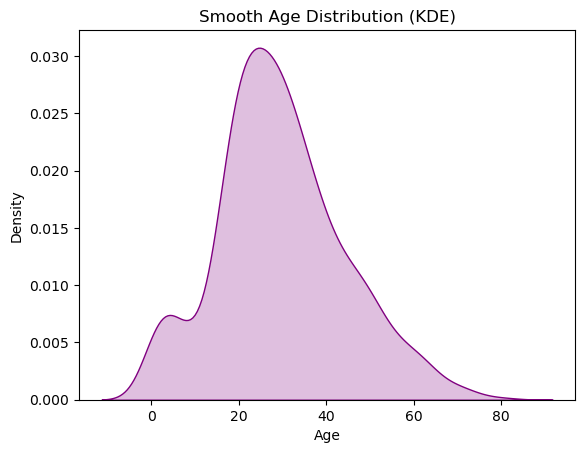

In [7]:
# KDE plot of Passenger Age
sns.kdeplot(df['Age'], fill=True, color='purple')
plt.title('Smooth Age Distribution (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

### B.3. Boxplot
A Boxplot is a visualization based on the **five-number summary** (Minimum, 25th percentile (Q1), Median (Q2), 75th percentile (Q3), Maximum). 

It is the single best way to spot **outliers** (values beyond $Q3 + 1.5 \times IQR$ or below $Q1 - 1.5 \times IQR$).

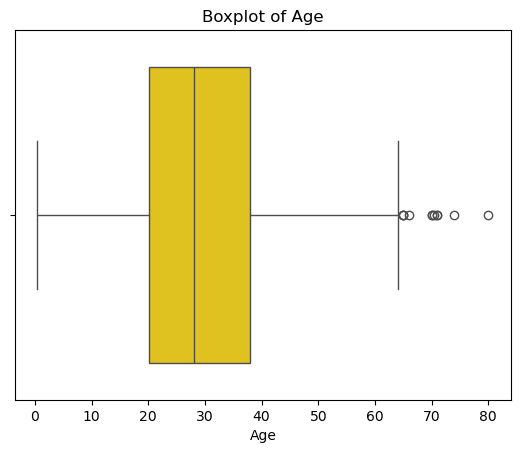

In [8]:
# Boxplot of Age to spot outliers
sns.boxplot(x=df['Age'], color='gold')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

### B.4. Numerical Statistics & Skewness
We can query central statistics directly. A **skewness score** tells us the symmetry:
*   **Skewness = 0**: Perfectly symmetric distribution.
*   **Skewness > 0**: Positively skewed (right-skewed tail, e.g., income/fare distribution).
*   **Skewness < 0**: Negatively skewed (left-skewed tail).

In [9]:
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Age Column Skewness: {df['Age'].skew():.4f}")
print(f"Fare Column Skewness: {df['Fare'].skew():.4f} (High right-skew expected!)")

Mean Age: 29.70
Median Age: 28.00
Age Column Skewness: 0.3891
Fare Column Skewness: 4.7873 (High right-skew expected!)
